In [106]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

run = 'a_20260402_222636'
# run = None  # Set to None to auto-detect the latest CSV file in results/

# Set to a CSV path string to force a specific file, e.g. '../results/my_file.csv'.
csv_file = f'../results/{run}/summary_{run}.csv' if run else None

results_candidates = [Path('results'), Path('../results')]
results_dir = next((p for p in results_candidates if p.exists() and p.is_dir()), None)
if results_dir is None:
    searched = [str(p.resolve()) for p in results_candidates]
    raise FileNotFoundError(f"Results folder not found. Searched: {searched}")

if csv_file is None:
    csv_candidates = sorted(results_dir.rglob('*.csv'))
    if not csv_candidates:
        raise FileNotFoundError(f"No .csv files found inside {results_dir.resolve()}")
    csv_file = str(csv_candidates[0])

print(f"Using CSV file: {csv_file}")
df = pd.read_csv(csv_file)

required_columns = ['instance', 'algorithm', 'objective_mean', 'exec_time_mean']
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

best_objectives_candidates = [
    Path('best_solutions') / 'best_objectives.csv',
    Path('../best_solutions') / 'best_objectives.csv',
]
best_objectives_path = next((p for p in best_objectives_candidates if p.exists()), None)
if best_objectives_path is None:
    searched = [str(p.resolve()) for p in best_objectives_candidates]
    raise FileNotFoundError(f"Best objectives file not found. Searched: {searched}")

best_df = pd.read_csv(best_objectives_path)
if 'instance' not in best_df.columns or 'best_objective' not in best_df.columns:
    raise ValueError("best_objectives.csv must contain columns: instance, best_objective")

if 'dataset' in df.columns and 'dataset' in best_df.columns:
    merge_columns = ['dataset', 'instance']
else:
    merge_columns = ['instance']

df = df.merge(best_df[merge_columns + ['best_objective']], on=merge_columns, how='left')
ordered_columns = [col for col in df.columns if col != 'best_objective'] + ['best_objective']
df = df[ordered_columns]

df.head()

Using CSV file: ../results/a_20260402_222636/summary_a_20260402_222636.csv


,dataset,algorithm,instance,total_runs,feasible_runs,infeasible_runs,timed_out_runs,objective_mean,objective_median,objective_mode,...,aisles_variance,aisles_std_dev,exec_time_mean,exec_time_median,exec_time_mode,exec_time_min,exec_time_max,exec_time_variance,exec_time_std_dev,best_objective
0,a,aisle_first_asc,instance_0001.txt,1,1,0,0,12.00,12.00,12.00,...,0.0,0.0,0.004773,0.004773,0.004773,0.004773,0.004773,0.0,0.0,15.000
1,a,aisle_first_asc,instance_0002.txt,1,1,0,0,2.00,2.00,2.00,...,0.0,0.0,0.000265,0.000265,0.000265,0.000265,0.000265,0.0,0.0,2.000
2,a,aisle_first_asc,instance_0003.txt,1,1,0,0,9.25,9.25,9.25,...,0.0,0.0,0.008418,0.008418,0.008418,0.008418,0.008418,0.0,0.0,12.000
3,a,aisle_first_asc,instance_0004.txt,1,1,0,0,3.50,3.50,3.50,...,0.0,0.0,0.002255,0.002255,0.002255,0.002255,0.002255,0.0,0.0,3.500
4,a,aisle_first_asc,instance_0005.txt,1,1,0,0,166.50,166.50,166.50,...,0.0,0.0,0.121779,0.121779,0.121779,0.121779,0.121779,0.0,0.0,177.875


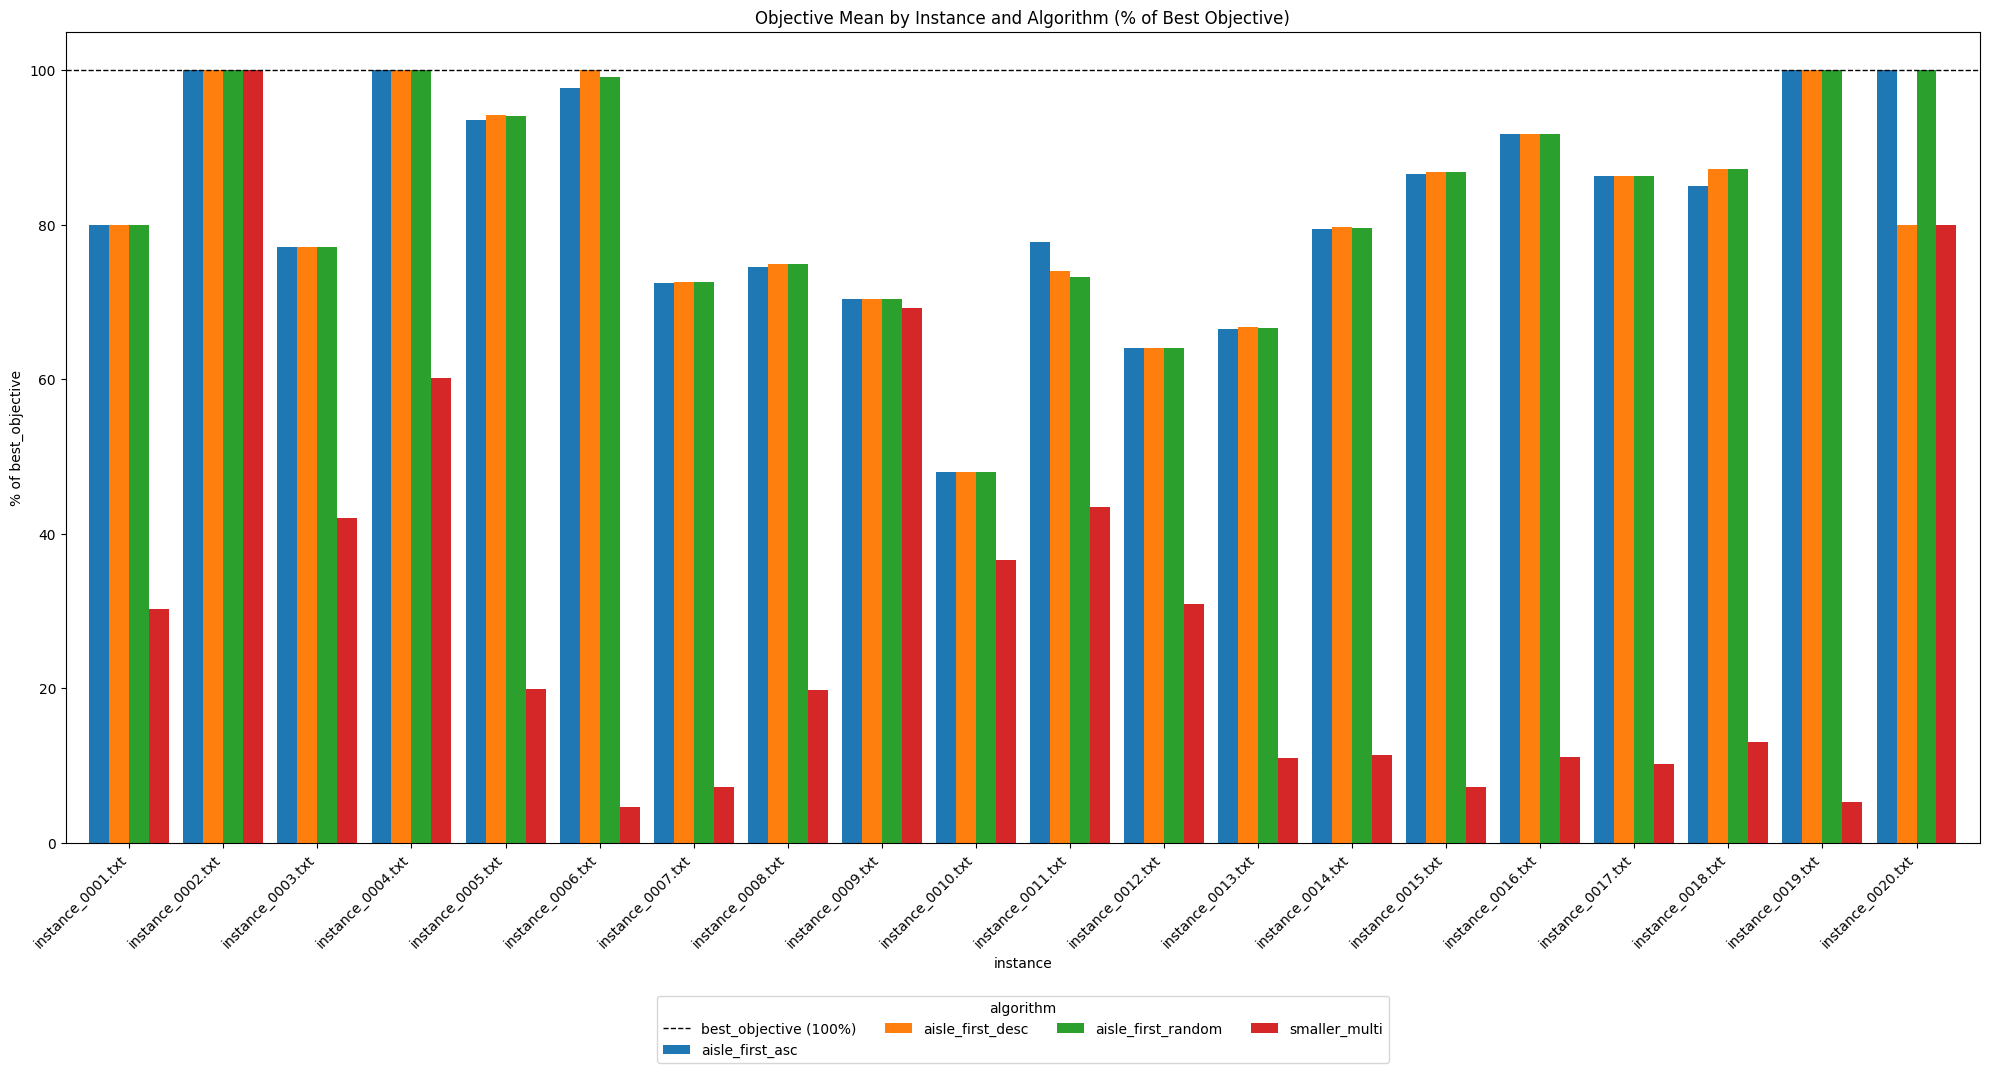

In [107]:
objective_plot = (
    df.pivot_table(
        index='instance',
        columns='algorithm',
        values='objective_mean',
        aggfunc='mean'
    )
    .sort_index()
    .fillna(0)
)

best_objective_by_instance = (
    df[['instance', 'best_objective']]
    .drop_duplicates(subset='instance')
    .set_index('instance')['best_objective']
)

objective_pct_plot = objective_plot.div(best_objective_by_instance, axis=0) * 100
objective_pct_plot = objective_pct_plot.replace([float('inf'), -float('inf')], 0).fillna(0)

ax = objective_pct_plot.plot(kind='bar', figsize=(20, 12), width=0.85)
ax.axhline(100, color='black', linestyle='--', linewidth=1, label='best_objective (100%)')
ax.set_xlabel('instance')
ax.set_ylabel('% of best_objective')
ax.set_title('Objective Mean by Instance and Algorithm (% of Best Objective)')
ax.legend(title='algorithm', loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=4)
plt.xticks(rotation=45, ha='right')
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

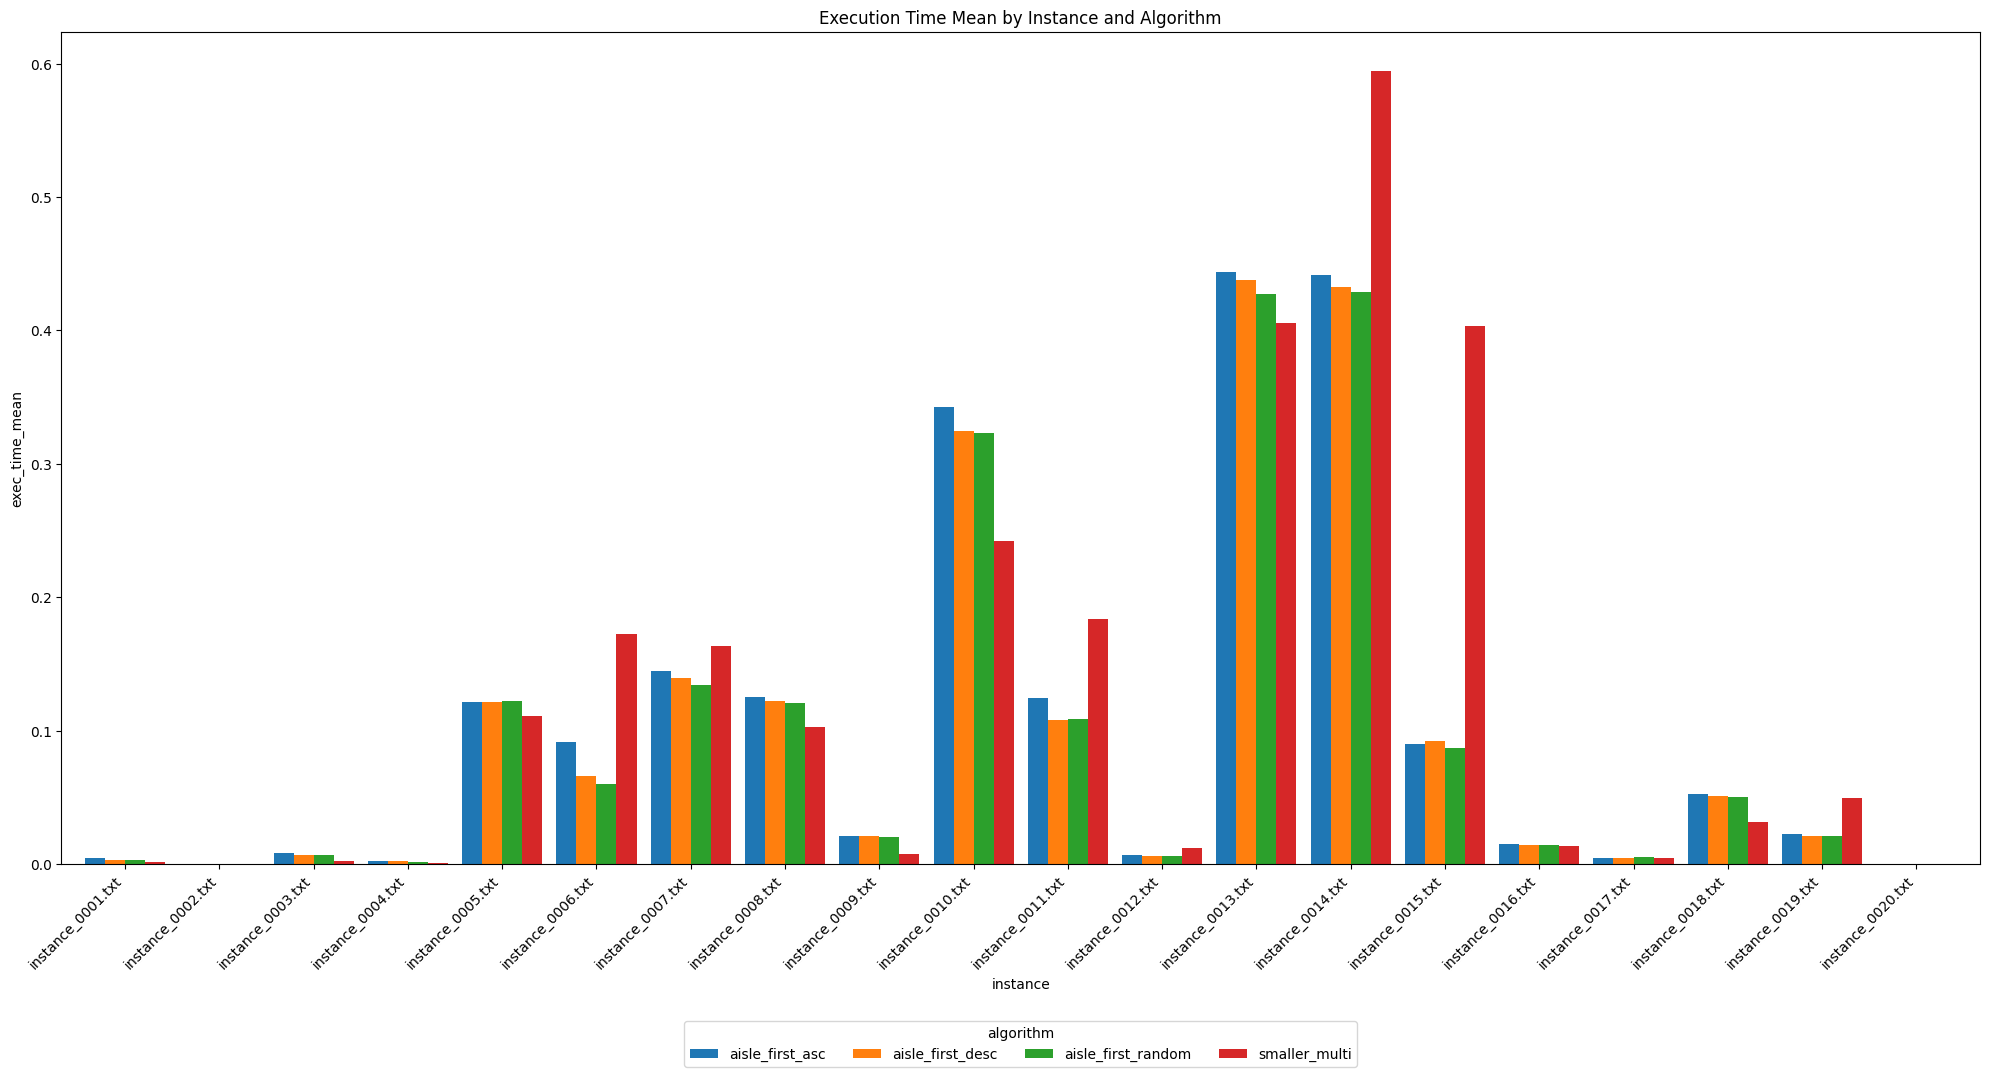

In [108]:
exec_time_plot = (
    df.pivot_table(
        index='instance',
        columns='algorithm',
        values='exec_time_mean',
        aggfunc='mean'
    )
    .sort_index()
    .fillna(0)
)

ax = exec_time_plot.plot(kind='bar', figsize=(20, 12), width=0.85)
ax.set_xlabel('instance')
ax.set_ylabel('exec_time_mean')
ax.set_title('Execution Time Mean by Instance and Algorithm')
ax.legend(title='algorithm', loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=4)
plt.xticks(rotation=45, ha='right')
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

In [109]:
# Remove the algorithms with infeasible runs
# infeasible_algorithms = df[df['objective_mean'] == 0]['algorithm'].unique()

# df = df[~df['algorithm'].isin(infeasible_algorithms)]

In [110]:
ranking_dataset_param = None  # e.g., 'a', 'b', 'x' or None for all datasets

ranking_base = df[["instance", "algorithm", "objective_mean", "exec_time_mean"]].copy()

if ranking_dataset_param is not None and "dataset" in df.columns:
    ranking_base = df[df["dataset"] == ranking_dataset_param][
        ["instance", "algorithm", "objective_mean", "exec_time_mean"]
    ].copy()

if ranking_base.empty:
    raise ValueError(f"No rows found for dataset={ranking_dataset_param!r}")


def build_final_ranking(base_df: pd.DataFrame, metric_column: str, ascending: bool) -> pd.DataFrame:
    metric_df = base_df.dropna(subset=[metric_column]).copy()
    if metric_df.empty:
        raise ValueError(f"No non-null values found for metric {metric_column!r}.")

    metric_df["N"] = metric_df.groupby("instance")["algorithm"].transform("nunique")
    metric_df["rank_class"] = metric_df.groupby("instance")[metric_column].rank(
        method="min", ascending=ascending
    ).astype(int)
    metric_df["score"] = metric_df["N"] - metric_df["rank_class"]

    final_ranking = (
        metric_df.groupby("algorithm", as_index=False)["score"]
        .agg(total_score="sum", average_score="mean", instances_count="count")
        .sort_values(["total_score", "average_score", "algorithm"], ascending=[False, False, True])
        .reset_index(drop=True)
    )
    final_ranking["final_rank"] = final_ranking["total_score"].rank(
        method="min", ascending=False
    ).astype(int)

    return final_ranking[
        ["final_rank", "algorithm", "total_score", "average_score", "instances_count"]
    ]


objective_ranking = build_final_ranking(
    ranking_base, metric_column="objective_mean", ascending=False
)
exec_time_ranking = build_final_ranking(
    ranking_base, metric_column="exec_time_mean", ascending=True
)

print(f"Dataset filter for ranking: {ranking_dataset_param!r}")
print("\nOBJECTIVE_MEAN - FINAL RANKING")
display(objective_ranking)
print("\nEXEC_TIME_MEAN - FINAL RANKING")
display(exec_time_ranking)

Dataset filter for ranking: None

OBJECTIVE_MEAN - FINAL RANKING


,final_rank,algorithm,total_score,average_score,instances_count
0,1,aisle_first_desc,57,2.85,20
1,2,aisle_first_random,54,2.70,20
2,3,aisle_first_asc,44,2.20,20
3,4,smaller_multi,4,0.20,20



EXEC_TIME_MEAN - FINAL RANKING


,final_rank,algorithm,total_score,average_score,instances_count
0,1,aisle_first_random,37,1.85,20
1,1,smaller_multi,37,1.85,20
2,3,aisle_first_desc,33,1.65,20
3,4,aisle_first_asc,13,0.65,20


/tmp/ipykernel_19026/1131620749.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(algorithms))


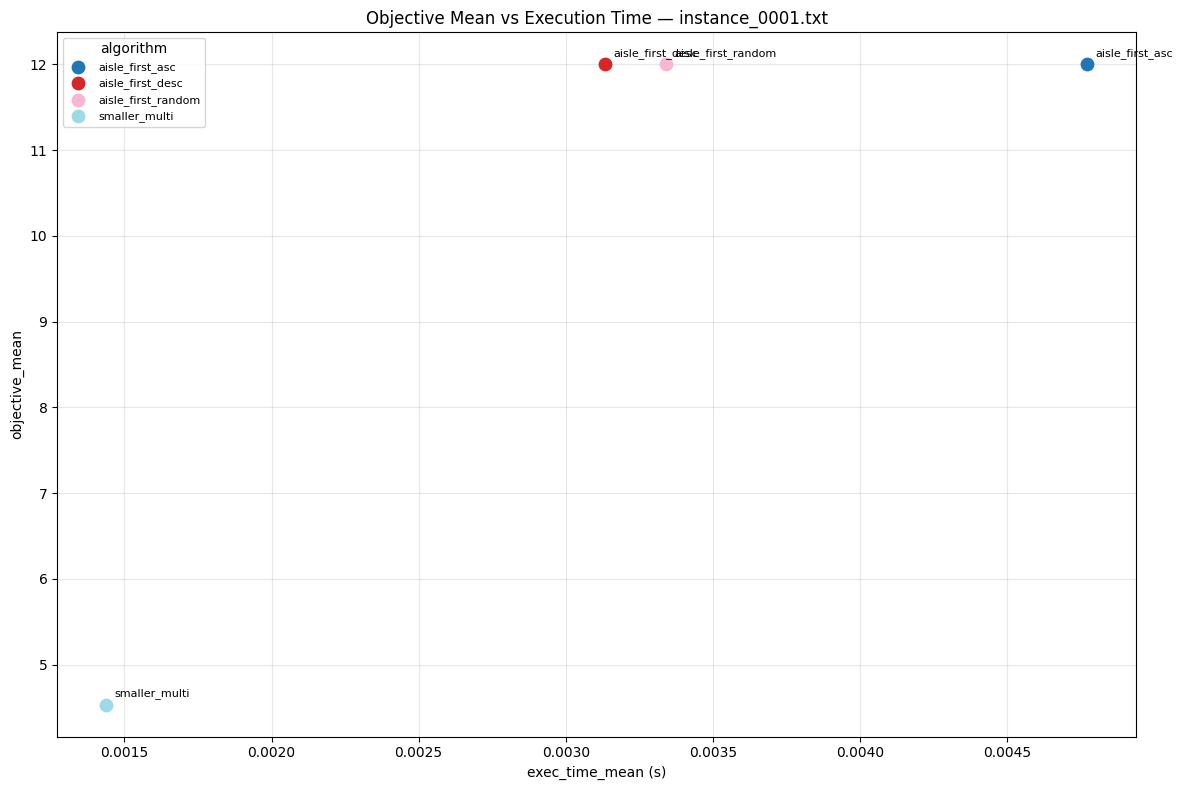

/tmp/ipykernel_19026/1131620749.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(algorithms))


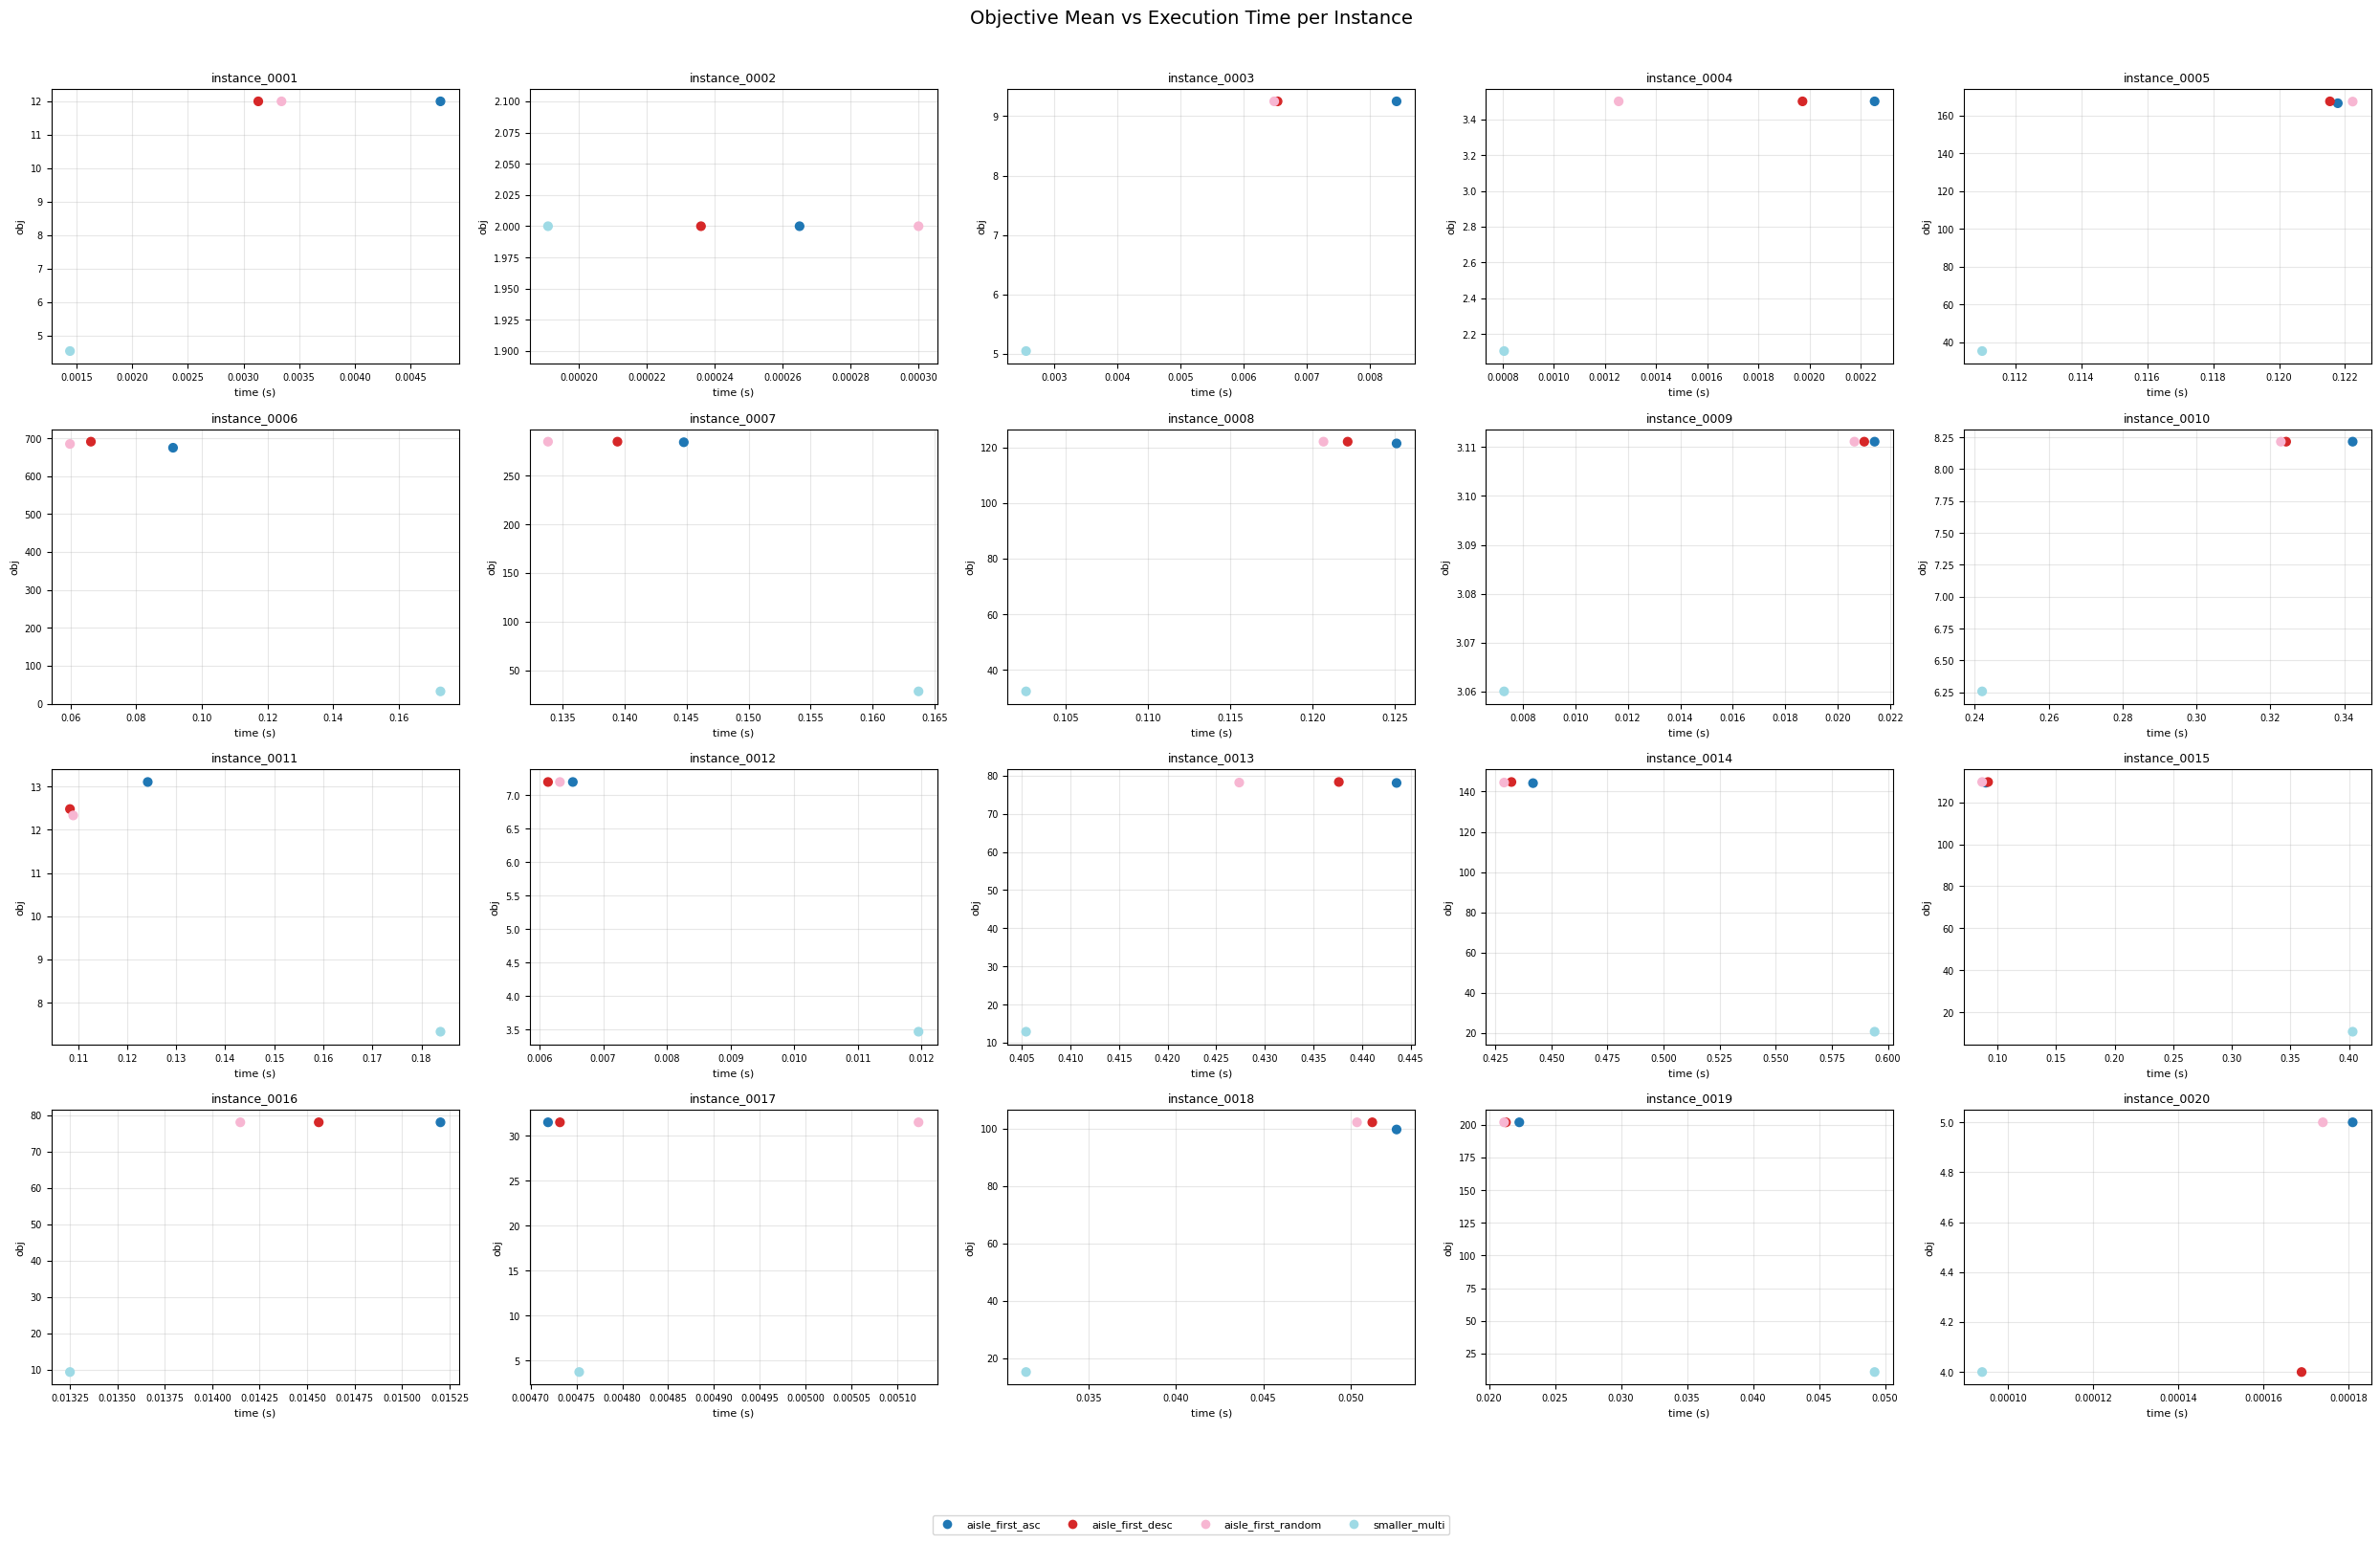

In [111]:
import math

def plot_obj_vs_time(df, instance):
    """Scatter plot of objective_mean vs exec_time_mean for a single instance."""
    subset = df[df['instance'] == instance].copy()
    if subset.empty:
        print(f"No data found for instance: {instance}")
        return

    algorithms = sorted(subset['algorithm'].unique())
    cmap = plt.cm.get_cmap('tab20', len(algorithms))
    color_map = {alg: cmap(i) for i, alg in enumerate(algorithms)}

    fig, ax = plt.subplots(figsize=(12, 8))
    for alg in algorithms:
        row = subset[subset['algorithm'] == alg]
        ax.scatter(row['exec_time_mean'], row['objective_mean'], s=80, zorder=3,
                   color=color_map[alg], label=alg)

    for _, row in subset.iterrows():
        ax.annotate(
            row['algorithm'],
            (row['exec_time_mean'], row['objective_mean']),
            textcoords='offset points', xytext=(6, 6), fontsize=8,
        )

    ax.set_xlabel('exec_time_mean (s)')
    ax.set_ylabel('objective_mean')
    ax.set_title(f'Objective Mean vs Execution Time — {instance}')
    ax.legend(title='algorithm', fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_obj_vs_time_grid(df):
    """Grid of scatter plots, one per instance."""
    instances = sorted(df['instance'].unique())
    n = len(instances)
    ncols = 5
    nrows = math.ceil(n / ncols)

    algorithms = sorted(df['algorithm'].unique())
    cmap = plt.cm.get_cmap('tab20', len(algorithms))
    color_map = {alg: cmap(i) for i, alg in enumerate(algorithms)}

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = axes.flatten()

    for idx, instance in enumerate(instances):
        ax = axes[idx]
        subset = df[df['instance'] == instance]
        colors = [color_map[a] for a in subset['algorithm']]
        ax.scatter(subset['exec_time_mean'], subset['objective_mean'], c=colors, s=40, zorder=3)
        ax.set_title(instance.replace('.txt', ''), fontsize=9)
        ax.set_xlabel('time (s)', fontsize=8)
        ax.set_ylabel('obj', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.3)

    for idx in range(n, len(axes)):
        axes[idx].set_visible(False)

    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[a],
               markersize=8, label=a) for a in algorithms]
    fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=8,
               bbox_to_anchor=(0.5, -0.02))
    fig.suptitle('Objective Mean vs Execution Time per Instance', fontsize=14)
    plt.tight_layout(rect=[0, 0.05, 1, 0.97])
    plt.show()


# Single instance plot
plot_obj_vs_time(df, 'instance_0001.txt')

# Grid plot for all instances
plot_obj_vs_time_grid(df)